In [1]:
!pip install google-play-scraper transformers torch matplotlib pandas


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.4 MB/s eta 0:00:00


In [2]:
from google_play_scraper import reviews, Sort
from transformers import pipeline
import csv
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
result, continuation_token = reviews(
    'com.bpjstku',
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=100
)

In [7]:
from transformers import pipeline

print("Load model IndoBERT...")

model_name = "w11wo/indonesian-roberta-base-sentiment-classifier"
sentiment_pipe = pipeline("sentiment-analysis", model=model_name)

Load model IndoBERT...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/328 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [8]:
print("Analisis sentimen...")

hasil_final = []

for i, review in enumerate(result):
    print(f"Proses {i+1}/{len(result)}", end='\r')

    teks = review['content']
    clean_text = teks[:512] if len(teks) > 512 else teks

    prediksi = sentiment_pipe(clean_text)[0]

    hasil_final.append({
        'userName': review['userName'],
        'score': review['score'],
        'at': review['at'],
        'content': teks,
        'sentiment': prediksi['label'],
        'confidence': round(prediksi['score'], 4)
    })

print("\nSelesai analisis!")

Analisis sentimen...
Proses 100/100
Selesai analisis!


In [9]:
import csv

filename = '/content/sample_data/hasil_sentimen.csv'

with open(filename, 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=[
        'userName','score','at','content','sentiment','confidence'
    ])
    writer.writeheader()
    writer.writerows(hasil_final)

print("File tersimpan di:", filename)

File tersimpan di: /content/sample_data/hasil_sentimen.csv


In [10]:
import pandas as pd

df = pd.DataFrame(hasil_final)

df.head()

,userName,score,at,content,sentiment,confidence
0,Liena Hartono,5,2026-04-29 17:16:19,"Tidak bisa membuka jmo setelah d perbaharui,dg...",negative,0.6524
1,Lestari,5,2026-04-29 14:14:10,👍👍👍,positive,0.4864
2,Hendra ika,3,2026-04-29 13:41:11,"kenpa setiap buka aplikasi selalu terhenti,mhn...",negative,0.8153
3,Parlin Nababan,5,2026-04-29 13:20:37,cukup,positive,0.5641
4,Tesa 1406,5,2026-04-29 13:18:24,proses mudah dan cepat,positive,0.8734


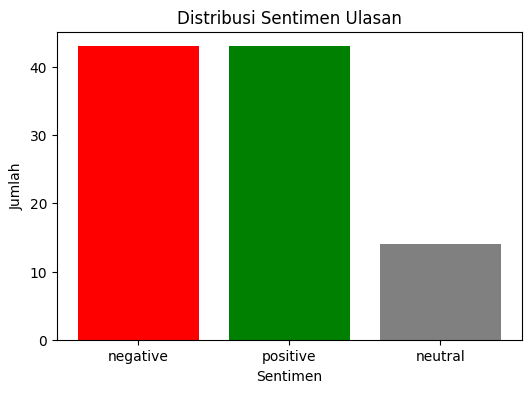

In [14]:
import matplotlib.pyplot as plt

# hitung jumlah tiap sentimen
sentiment_counts = df['sentiment'].value_counts()

# warna custom
colors = {
    'positive': 'green',
    'neutral': 'gray',
    'negative': 'red'
}

# mapping warna sesuai label
bar_colors = [colors.get(label, 'blue') for label in sentiment_counts.index]

# plot
plt.figure(figsize=(6,4))
plt.bar(sentiment_counts.index, sentiment_counts.values, color=bar_colors)

plt.title('Distribusi Sentimen Ulasan')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah')

plt.show()

In [13]:
!ls /content/sample_data

anscombe.json		      hasil_sentimen.csv     README.md
california_housing_test.csv   mnist_test.csv
california_housing_train.csv  mnist_train_small.csv
